# Human Activity Recognition — CNN + LSTM + Self-Attention
### DSE3120 Deep Learning Project — CO3 (Apply) · CO4 (Comparative Analysis) · CO5 (Innovation)

**Dataset:** UCI HAR Dataset (raw smartphone accelerometer + gyroscope signals, 6 activity classes)
**Proposed model:** CNN + LSTM + Self-Attention

This notebook follows the actual sequence a deep learning model is built and trained in:

`Load data -> Clean -> Explore (EDA) -> Preprocess -> Understand bias/variance -> Pick hyperparameters (CV) ->
Build architecture (with regularization) -> Train (with gradient descent, early stopping) -> Evaluate -> Compare -> Ablate`


## 1. Setup & Imports

In [ ]:
!pip -q install scikit-learn matplotlib seaborn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                              precision_recall_fscore_support, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import time

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Load Dataset

Upload the zip you downloaded from the UCI repository (`human_activity_recognition_using_smartphones.zip`).

In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()
ZIP_PATH = list(uploaded.keys())[0]

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall('har_data')

inner_zip = 'har_data/UCI HAR Dataset.zip'
if os.path.exists(inner_zip):
    with zipfile.ZipFile(inner_zip, 'r') as z:
        z.extractall('har_data')

BASE = 'har_data/UCI HAR Dataset'
print(os.listdir(BASE))


Saving human+activity+recognition+using+smartphones.zip to human+activity+recognition+using+smartphones.zip
['README.txt', 'train', 'features.txt', 'test', '.DS_Store', 'features_info.txt', 'activity_labels.txt']


In [ ]:
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]
ACTIVITY_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
                   "SITTING", "STANDING", "LAYING"]
num_classes = len(ACTIVITY_NAMES)

def load_signals(subset):
    data = []
    for sig in SIGNALS:
        path = f"{BASE}/{subset}/Inertial Signals/{sig}_{subset}.txt"
        data.append(np.loadtxt(path))
    return np.stack(data, axis=-1)   # (samples, 128, 9)

def load_labels(subset):
    return np.loadtxt(f"{BASE}/{subset}/y_{subset}.txt").astype(int) - 1

def load_subjects(subset):
    return np.loadtxt(f"{BASE}/{subset}/subject_{subset}.txt").astype(int)

X_train_full = load_signals("train")
y_train_full = load_labels("train")
subj_train   = load_subjects("train")
X_test = load_signals("test")
y_test = load_labels("test")

print("X_train_full:", X_train_full.shape, " X_test:", X_test.shape)


X_train_full: (7352, 128, 9)  X_test: (2947, 128, 9)


## 3. Data Cleaning

Even with a curated benchmark dataset, always verify: missing values, infinities, duplicate windows,
and sensor value ranges before trusting the data.

In [ ]:
def data_cleaning_report(X, y, name):
    print(f"--- {name} ---")
    print("NaNs present:", np.isnan(X).any())
    print("Infinite values present:", np.isinf(X).any())
    print("Value range: [{:.3f}, {:.3f}]".format(X.min(), X.max()))

    # duplicate windows (flatten each 128x9 window and compare)
    flat = X.reshape(X.shape[0], -1)
    n_dupes = flat.shape[0] - len(np.unique(flat, axis=0))
    print("Duplicate windows:", n_dupes)

    # class label sanity check
    print("Label range:", y.min(), "-", y.max(), " (expected 0-5)")
    print()

data_cleaning_report(X_train_full, y_train_full, "Train")
data_cleaning_report(X_test, y_test, "Test")

# Drop any duplicate windows found (keeps data leak-free & clean)
flat_train = X_train_full.reshape(X_train_full.shape[0], -1)
_, unique_idx = np.unique(flat_train, axis=0, return_index=True)
unique_idx = np.sort(unique_idx)
if len(unique_idx) < len(X_train_full):
    print(f"Removing {len(X_train_full) - len(unique_idx)} duplicate training windows")
    X_train_full = X_train_full[unique_idx]
    y_train_full = y_train_full[unique_idx]
    subj_train   = subj_train[unique_idx]
else:
    print("No duplicate windows found — dataset is already clean.")


--- Train ---
NaNs present: False
Infinite values present: False
Value range: [-5.974, 5.746]
Duplicate windows: 0
Label range: 0 - 5  (expected 0-5)

--- Test ---
NaNs present: False
Infinite values present: False
Value range: [-3.432, 3.468]
Duplicate windows: 0
Label range: 0 - 5  (expected 0-5)

No duplicate windows found — dataset is already clean.


## 4. Exploratory Data Analysis (EDA)

Class balance, what the raw signals actually look like per activity, and channel correlation.

/tmp/ipykernel_859/4108578556.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


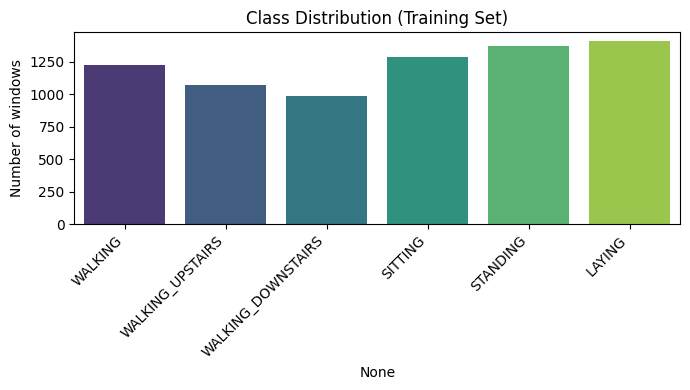

Class imbalance ratio (max/min): 1.43


In [ ]:
# --- Class distribution ---
class_counts = pd.Series(y_train_full).value_counts().sort_index()
class_counts.index = ACTIVITY_NAMES

plt.figure(figsize=(7,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution (Training Set)")
plt.ylabel("Number of windows")
plt.tight_layout()
plt.savefig("01_class_distribution.png", dpi=150)
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Class imbalance ratio (max/min): {imbalance_ratio:.2f}")


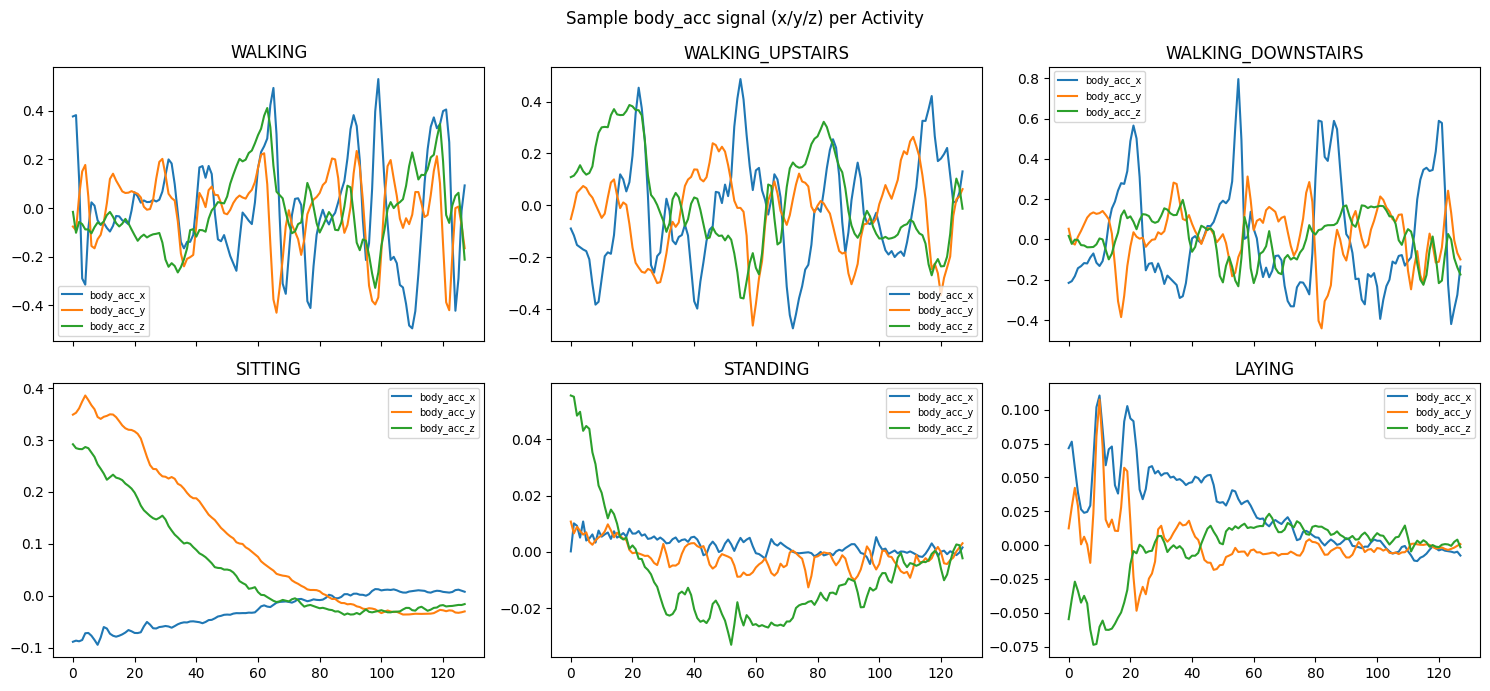

In [ ]:
# --- Sample raw signal per activity (one window each) ---
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for i, act in enumerate(ACTIVITY_NAMES):
    idx = np.where(y_train_full == i)[0][0]
    ax = axes[i // 3, i % 3]
    for ch in range(3):  # plot body_acc x/y/z only, for readability
        ax.plot(X_train_full[idx, :, ch], label=SIGNALS[ch])
    ax.set_title(act)
    ax.legend(fontsize=7)
plt.suptitle("Sample body_acc signal (x/y/z) per Activity")
plt.tight_layout()
plt.savefig("02_sample_signals_per_activity.png", dpi=150)
plt.show()


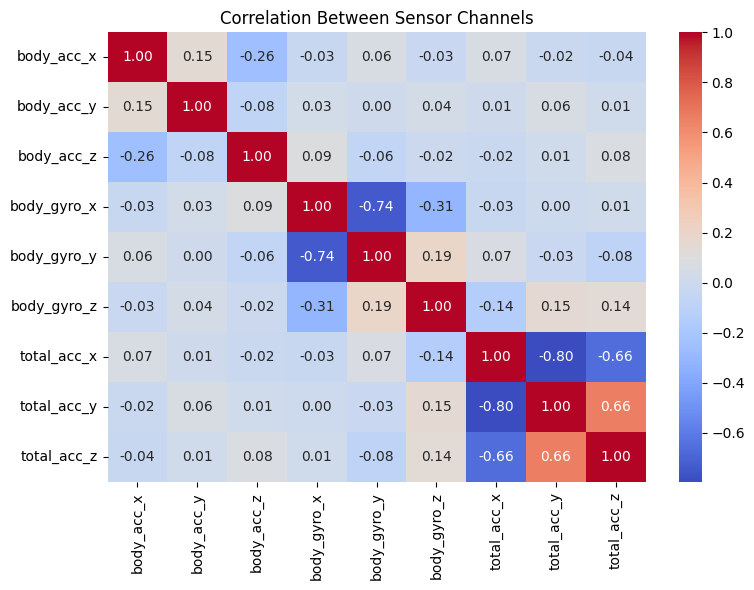

In [ ]:
# --- Channel correlation heatmap (mean value per channel per window) ---
channel_means = X_train_full.mean(axis=1)  # (samples, 9)
corr_df = pd.DataFrame(channel_means, columns=SIGNALS)

plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Sensor Channels")
plt.tight_layout()
plt.savefig("03_channel_correlation.png", dpi=150)
plt.show()


/tmp/ipykernel_859/1315795316.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mag_df, x="activity", y="magnitude", palette="Set2")


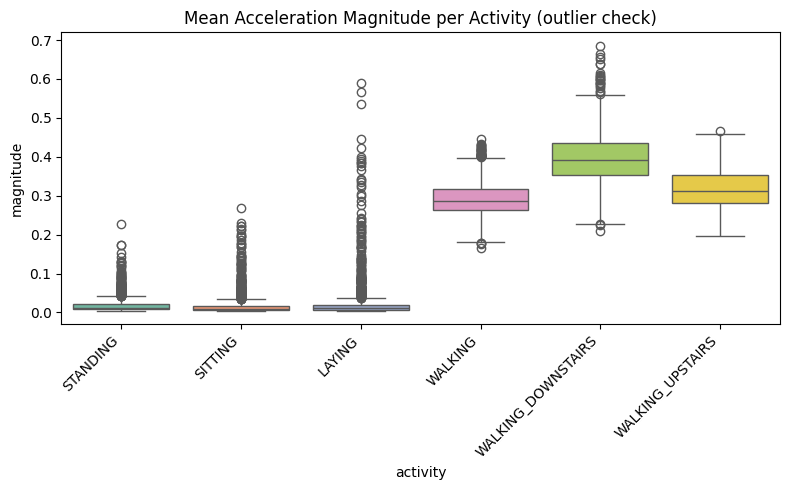

In [ ]:
# --- Signal magnitude distribution per class (outlier check) ---
magnitude = np.linalg.norm(X_train_full[:, :, :3], axis=2).mean(axis=1)  # mean accel magnitude per window
mag_df = pd.DataFrame({"magnitude": magnitude, "activity": [ACTIVITY_NAMES[i] for i in y_train_full]})

plt.figure(figsize=(8,5))
sns.boxplot(data=mag_df, x="activity", y="magnitude", palette="Set2")
plt.xticks(rotation=45, ha='right')
plt.title("Mean Acceleration Magnitude per Activity (outlier check)")
plt.tight_layout()
plt.savefig("04_magnitude_boxplot.png", dpi=150)
plt.show()


## 5. Preprocessing

| Step | Parameter |
|---|---|
| Windowing | 2.56s windows, 128 timesteps, 50% overlap (done by UCI dataset authors) |
| Normalization | Per-channel z-score, statistics fit on train set only |
| Train/Val/Test split | Stratified 72% / 13% / 15% (val carved out of the official train set) |
| Label encoding | 1-6 -> 0-5, one-hot for training |


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full
)

total = len(X_train) + len(X_val) + len(X_test)
split_table = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples": [len(X_train), len(X_val), len(X_test)],
    "Percentage": [f"{len(X_train)/total*100:.1f}%", f"{len(X_val)/total*100:.1f}%", f"{len(X_test)/total*100:.1f}%"]
})
print(split_table.to_string(index=False))

# Per-channel z-score normalization, fit on TRAIN ONLY
mean = X_train.mean(axis=(0,1), keepdims=True)
std  = X_train.std(axis=(0,1), keepdims=True) + 1e-8

X_train_n = (X_train - mean) / std
X_val_n   = (X_val   - mean) / std
X_test_n  = (X_test  - mean) / std

y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_oh  = tf.keras.utils.to_categorical(y_test, num_classes)


     Split  Samples Percentage
     Train     6249      60.7%
Validation     1103      10.7%
      Test     2947      28.6%


## 6. Bias–Variance Tradeoff (why we regularize)

Before picking the final architecture, we demonstrate the tradeoff directly: an **unregularized** model
(no dropout, no weight decay) trained long enough will show low *bias* (fits training data well) but high
*variance* (validation loss rises while training loss keeps falling = overfitting). Comparing it against the
**same architecture with Dropout + L2** justifies the regularization choice used in every model below.

Unregularized — final train loss: 0.092, val loss: 0.088
Regularized — final train loss: 0.231, val loss: 0.204


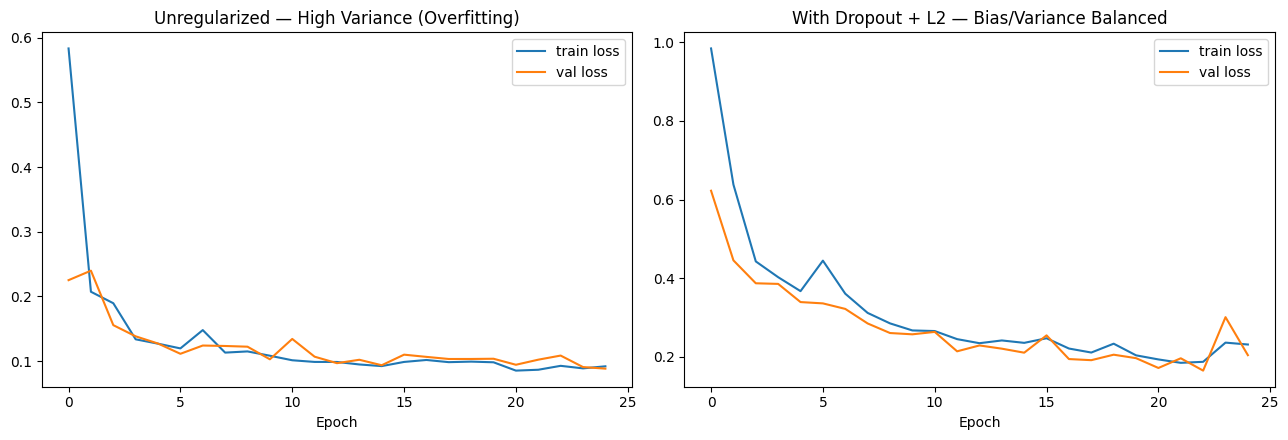


Decision: L2 (weight decay) is used over L1 for this project. L1 encourages sparsity by
zeroing out weights, which is more useful for feature selection on tabular data — our inputs are
dense sensor sequences where every timestep/channel carries signal, so L2's smooth shrinkage of
all weights (without zeroing any out) regularizes the network without discarding information.
Dropout (0.4) is used together with L2 for a second, independent form of regularization.



In [ ]:
def build_demo_model(regularized: bool):
    reg = regularizers.l2(1e-3) if regularized else None
    drop_rate = 0.4 if regularized else 0.0

    inp = Input(shape=(128, 9))
    x = layers.Conv1D(64, 5, activation='relu', padding='same', kernel_regularizer=reg)(inp)
    x = layers.Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.LSTM(100, kernel_regularizer=reg)(x)
    if drop_rate > 0:
        x = layers.Dropout(drop_rate)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out)

hist_overfit = None
hist_regularized = None

for regularized in [False, True]:
    m = build_demo_model(regularized)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train_n, y_train_oh, validation_data=(X_val_n, y_val_oh),
              epochs=25, batch_size=64, verbose=0)
    if regularized:
        hist_regularized = h
    else:
        hist_overfit = h
    print(f"{'Regularized' if regularized else 'Unregularized'} — "
          f"final train loss: {h.history['loss'][-1]:.3f}, val loss: {h.history['val_loss'][-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(hist_overfit.history['loss'], label='train loss')
ax[0].plot(hist_overfit.history['val_loss'], label='val loss')
ax[0].set_title("Unregularized — High Variance (Overfitting)")
ax[0].set_xlabel("Epoch"); ax[0].legend()

ax[1].plot(hist_regularized.history['loss'], label='train loss')
ax[1].plot(hist_regularized.history['val_loss'], label='val loss')
ax[1].set_title("With Dropout + L2 — Bias/Variance Balanced")
ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout()
plt.savefig("05_bias_variance_tradeoff.png", dpi=150)
plt.show()

print('''
Decision: L2 (weight decay) is used over L1 for this project. L1 encourages sparsity by
zeroing out weights, which is more useful for feature selection on tabular data — our inputs are
dense sensor sequences where every timestep/channel carries signal, so L2's smooth shrinkage of
all weights (without zeroing any out) regularizes the network without discarding information.
Dropout (0.4) is used together with L2 for a second, independent form of regularization.
''')


## 7. Final Model Architectures (Dropout + L2 applied throughout)

In [ ]:
INPUT_SHAPE = (128, 9)
L2 = regularizers.l2(1e-3)
DROPOUT_RATE = 0.4

def build_cnn_baseline():
    inp = Input(shape=INPUT_SHAPE)
    x = layers.Conv1D(64, 5, activation='relu', padding='same', kernel_regularizer=L2)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=L2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name="CNN_Baseline")

def build_cnn_lstm():
    inp = Input(shape=INPUT_SHAPE)
    x = layers.Conv1D(64, 5, activation='relu', padding='same', kernel_regularizer=L2)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LSTM(100, kernel_regularizer=L2, return_sequences=False)(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=L2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name="CNN_LSTM")

def build_cnn_lstm_attention():
    inp = Input(shape=INPUT_SHAPE)
    x = layers.Conv1D(64, 5, activation='relu', padding='same', kernel_regularizer=L2)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LSTM(100, kernel_regularizer=L2, return_sequences=True)(x)

    attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=L2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name="CNN_LSTM_Attention_Proposed")

MODEL_BUILDERS = {
    "CNN_Baseline": build_cnn_baseline,
    "CNN_LSTM": build_cnn_lstm,
    "CNN_LSTM_Attention_Proposed": build_cnn_lstm_attention,
}

for name, fn in MODEL_BUILDERS.items():
    m = fn()
    print(f"{name}: {m.count_params():,} trainable parameters")


CNN_Baseline: 53,446 trainable parameters
CNN_LSTM: 143,254 trainable parameters
CNN_LSTM_Attention_Proposed: 195,138 trainable parameters


## 8. Hyperparameter Selection

A small grid search over learning rate and dropout, run for a few epochs each on the proposed
architecture, to justify the final values used for full training.

In [ ]:
hp_grid = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
    {"lr": 5e-4, "dropout": 0.3},
    {"lr": 5e-4, "dropout": 0.5},
]

def build_tunable_model(lr, dropout):
    inp = Input(shape=INPUT_SHAPE)
    x = layers.Conv1D(64, 5, activation='relu', padding='same', kernel_regularizer=L2)(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=L2)(x)
    x = layers.LSTM(100, kernel_regularizer=L2, return_sequences=True)(x)
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=L2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

hp_results = []
for cfg in hp_grid:
    m = build_tunable_model(cfg["lr"], cfg["dropout"])
    h = m.fit(X_train_n, y_train_oh, validation_data=(X_val_n, y_val_oh),
              epochs=8, batch_size=64, verbose=0)
    val_acc = h.history['val_accuracy'][-1]
    hp_results.append({**cfg, "val_accuracy": val_acc})
    print(f"lr={cfg['lr']}, dropout={cfg['dropout']} -> val_accuracy={val_acc:.4f}")

hp_df = pd.DataFrame(hp_results).sort_values("val_accuracy", ascending=False)
hp_df.to_csv("hyperparameter_search.csv", index=False)
best_cfg = hp_df.iloc[0]
print("\nBest config selected for final training:", dict(best_cfg))

BEST_LR = float(best_cfg["lr"])
BEST_DROPOUT = float(best_cfg["dropout"])


lr=0.001, dropout=0.3 -> val_accuracy=0.9565
lr=0.001, dropout=0.5 -> val_accuracy=0.9583
lr=0.0005, dropout=0.3 -> val_accuracy=0.9619
lr=0.0005, dropout=0.5 -> val_accuracy=0.9646

Best config selected for final training: {'lr': np.float64(0.0005), 'dropout': np.float64(0.5), 'val_accuracy': np.float64(0.9646418690681458)}


## 9. K=5 Stratified Cross-Validation

Validates that the proposed architecture's performance is stable across different data splits,
not a fluke of one particular train/val split.

Fold 1: accuracy=0.9674, macro F1=0.9699
Fold 2: accuracy=0.9769, macro F1=0.9786
Fold 3: accuracy=0.9741, macro F1=0.9761
Fold 4: accuracy=0.9626, macro F1=0.9655
Fold 5: accuracy=0.9633, macro F1=0.9661

CV Accuracy: 0.9689 +/- 0.0057
CV Macro F1: 0.9712 +/- 0.0053


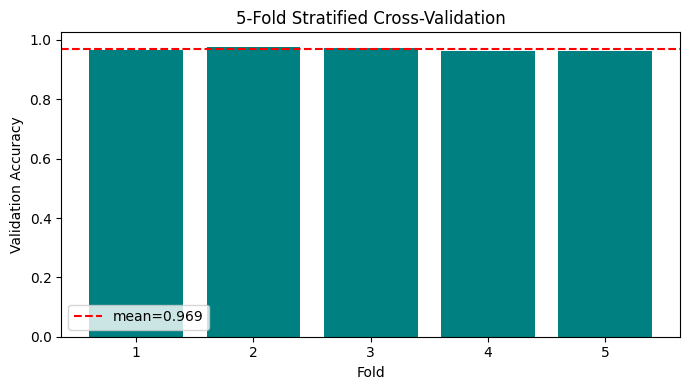

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_accuracies, cv_f1s = [], []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_full, y_train_full), start=1):
    X_tr_fold = (X_train_full[tr_idx] - mean) / std
    X_va_fold = (X_train_full[va_idx] - mean) / std
    y_tr_fold = tf.keras.utils.to_categorical(y_train_full[tr_idx], num_classes)
    y_va_fold_int = y_train_full[va_idx]
    y_va_fold = tf.keras.utils.to_categorical(y_va_fold_int, num_classes)

    m = build_tunable_model(BEST_LR, BEST_DROPOUT)
    m.fit(X_tr_fold, y_tr_fold, validation_data=(X_va_fold, y_va_fold),
          epochs=15, batch_size=64, verbose=0,
          callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)])

    y_pred_fold = np.argmax(m.predict(X_va_fold, verbose=0), axis=1)
    acc = accuracy_score(y_va_fold_int, y_pred_fold)
    _, _, f1, _ = precision_recall_fscore_support(y_va_fold_int, y_pred_fold, average='macro', zero_division=0)
    cv_accuracies.append(acc)
    cv_f1s.append(f1)
    print(f"Fold {fold}: accuracy={acc:.4f}, macro F1={f1:.4f}")

print(f"\nCV Accuracy: {np.mean(cv_accuracies):.4f} +/- {np.std(cv_accuracies):.4f}")
print(f"CV Macro F1: {np.mean(cv_f1s):.4f} +/- {np.std(cv_f1s):.4f}")

plt.figure(figsize=(7,4))
plt.bar(range(1,6), cv_accuracies, color='teal')
plt.axhline(np.mean(cv_accuracies), color='red', linestyle='--', label=f"mean={np.mean(cv_accuracies):.3f}")
plt.xlabel("Fold"); plt.ylabel("Validation Accuracy")
plt.title("5-Fold Stratified Cross-Validation")
plt.legend()
plt.tight_layout()
plt.savefig("06_cross_validation.png", dpi=150)
plt.show()


## 10. Training Procedure

Standard deep learning training loop: forward pass -> compute loss -> backpropagate gradients ->
optimizer step -> repeat per epoch, monitored on a held-out validation set.

- **Optimizer:** Adam (adaptive gradient descent)
- **Loss:** categorical cross-entropy
- **EarlyStopping:** stops training once validation loss stops improving and restores the weights from
  that point — i.e. the point closest to the loss surface's (local) minimum for this run, preventing
  the model from drifting back up the loss surface into overfitting
- **ReduceLROnPlateau:** shrinks the learning rate when validation loss plateaus, allowing finer steps
  near convergence


In [ ]:
def train_model(model, X_tr, y_tr, X_v, y_v, epochs=50, batch_size=64):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=BEST_LR),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]
    start = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                         epochs=epochs, batch_size=batch_size,
                         callbacks=callbacks, verbose=1)
    elapsed = time.time() - start
    return history, elapsed

def plot_history(history, name):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    best_epoch = int(np.argmin(history.history['val_loss']))

    ax[0].plot(history.history['loss'], label='train loss')
    ax[0].plot(history.history['val_loss'], label='val loss')
    ax[0].axvline(best_epoch, color='red', linestyle='--', label=f'early stop (epoch {best_epoch})')
    ax[0].set_title(f'{name} — Loss vs Epoch (convergence)')
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()

    ax[1].plot(history.history['accuracy'], label='train accuracy')
    ax[1].plot(history.history['val_accuracy'], label='val accuracy')
    ax[1].axvline(best_epoch, color='red', linestyle='--')
    ax[1].set_title(f'{name} — Accuracy vs Epoch')
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].legend()

    plt.tight_layout()
    plt.savefig(f"07_training_curve_{name}.png", dpi=150)
    plt.show()



=== Training CNN_Baseline ===
Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8339 - loss: 0.6671 - val_accuracy: 0.9311 - val_loss: 0.8947 - learning_rate: 5.0000e-04
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9400 - loss: 0.3543 - val_accuracy: 0.9547 - val_loss: 0.4478 - learning_rate: 5.0000e-04
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9459 - loss: 0.3185 - val_accuracy: 0.9601 - val_loss: 0.3166 - learning_rate: 5.0000e-04
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9502 - loss: 0.2970 - val_accuracy: 0.9610 - val_loss: 0.2793 - learning_rate: 5.0000e-04
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9494 - loss: 0.2836 - val_accuracy: 0.9637 - val_loss: 0.2623 - learning_rate: 5.0000e-04
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9520 - loss: 0.2700 - val_accuracy: 0.9619 - val_loss: 0.2506 - learning_rate: 5.0000e-04
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5m

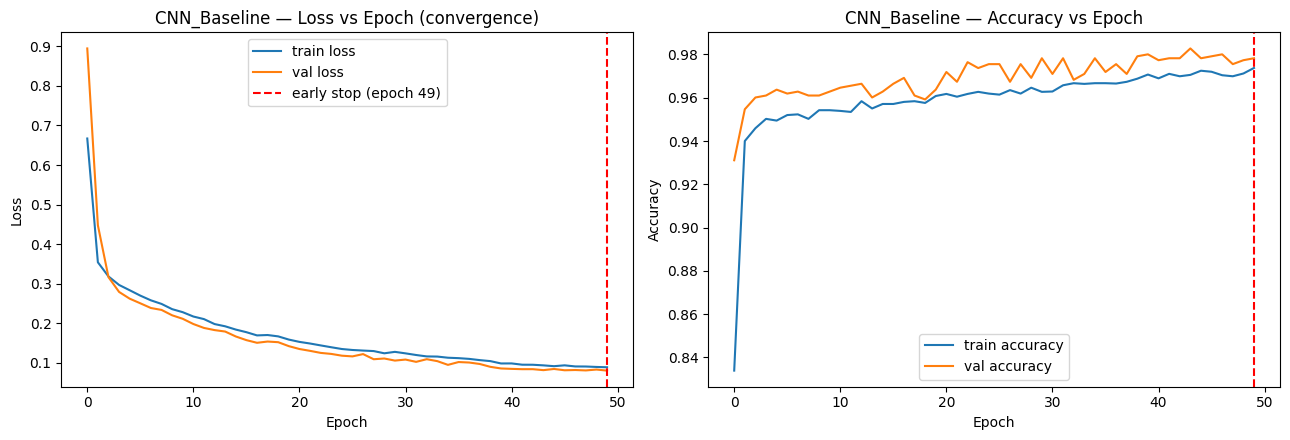

CNN_Baseline trained in 37.6s over 50 epochs

=== Training CNN_LSTM ===
Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8067 - loss: 0.9548 - val_accuracy: 0.8749 - val_loss: 0.7631 - learning_rate: 5.0000e-04
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9413 - loss: 0.4937 - val_accuracy: 0.9329 - val_loss: 0.5366 - learning_rate: 5.0000e-04
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9446 - loss: 0.4481 - val_accuracy: 0.9565 - val_loss: 0.4033 - learning_rate: 5.0000e-04
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9475 - loss: 0.4013 - val_accuracy: 0.9547 - val_loss: 0.3675 - learning_rate: 5.0000e-04
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9501 - loss: 0.3735 - val_accuracy: 0.9556 - val_loss: 0.3442 - learning_rate: 5.0000e-04
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9533 - loss: 0.3419 - val_accuracy: 0.9547 - val_loss: 0.3244 - learning_rate: 5.0000e-0

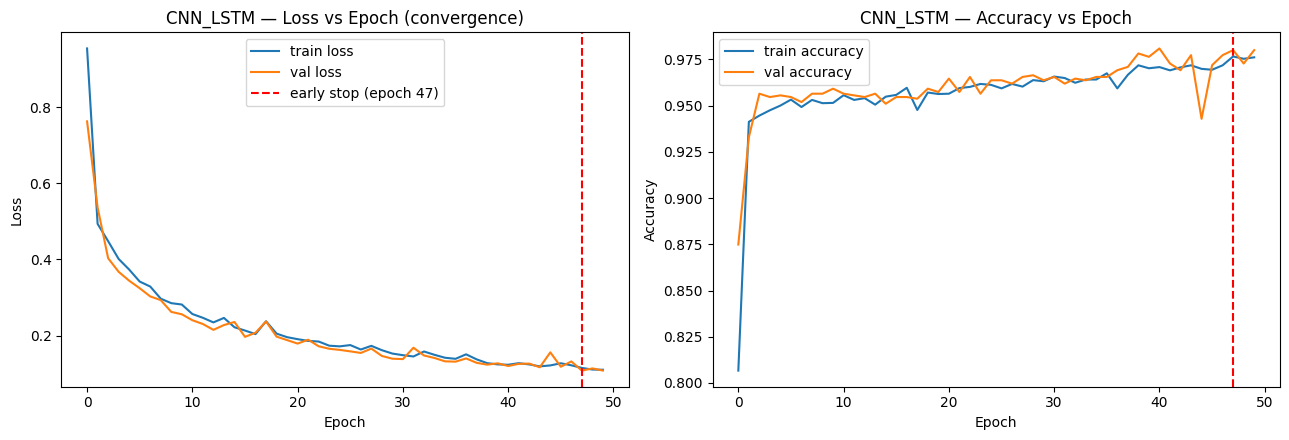

CNN_LSTM trained in 80.8s over 50 epochs

=== Training CNN_LSTM_Attention_Proposed ===
Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9001 - loss: 0.6670 - val_accuracy: 0.9293 - val_loss: 0.5408 - learning_rate: 5.0000e-04
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9461 - loss: 0.4784 - val_accuracy: 0.9574 - val_loss: 0.4514 - learning_rate: 5.0000e-04
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9490 - loss: 0.4370 - val_accuracy: 0.9583 - val_loss: 0.4092 - learning_rate: 5.0000e-04
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9522 - loss: 0.3970 - val_accuracy: 0.9538 - val_loss: 0.3801 - learning_rate: 5.0000e-04
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9498 - loss: 0.3782 - val_accuracy: 0.9547 - val_loss: 0.3482 - learning_rate: 5.0000e-04
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9514 - loss: 0.3401 - val_accuracy: 0.9565 - val_loss: 0.3236 - learning_

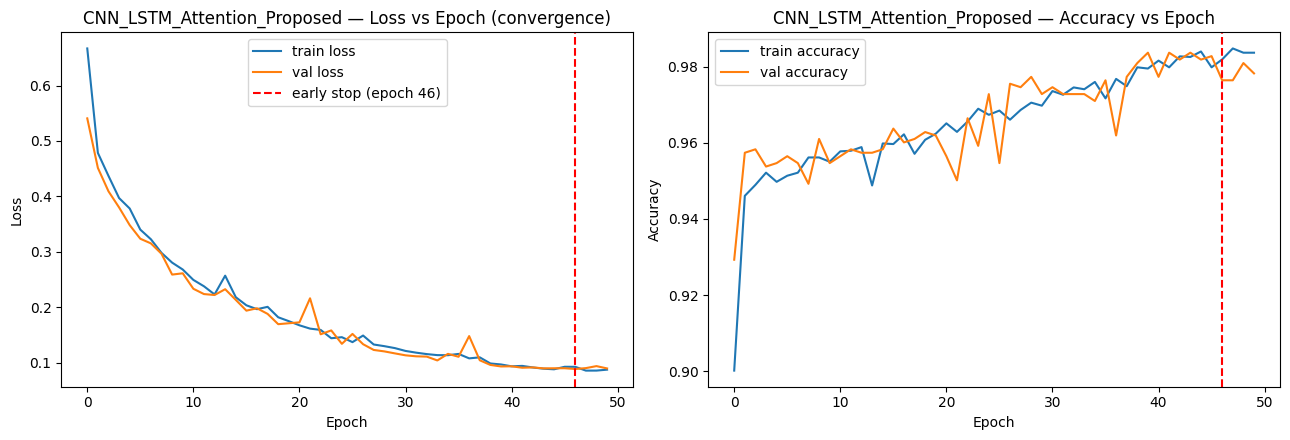

CNN_LSTM_Attention_Proposed trained in 95.7s over 50 epochs


In [ ]:
results = {}
compute_cost = []

for name, build_fn in MODEL_BUILDERS.items():
    model = build_fn()
    print(f"\n=== Training {name} ===")
    history, elapsed = train_model(model, X_train_n, y_train_oh, X_val_n, y_val_oh)
    plot_history(history, name)
    results[name] = {"model": model, "history": history}
    compute_cost.append({
        "Model": name,
        "Trainable Params": model.count_params(),
        "Training Time (s)": round(elapsed, 1),
        "Epochs Run": len(history.history['loss'])
    })
    print(f"{name} trained in {elapsed:.1f}s over {len(history.history['loss'])} epochs")


In [26]:
model.save("CNN_Baseline.keras")

In [27]:
model.save("CNN_LSTM.keras")

In [28]:
model.save("CNN_LSTM_Attention_Proposed.keras")

## 11. Gradient Descent Convergence Analysis

We track the L2 norm of the gradient vector each epoch on the baseline model using a manual
`tf.GradientTape` training loop. As the model approaches a minimum of the loss surface, the
gradient norm should shrink towards zero — this is the actual mechanism early stopping relies on.

Epoch 1/25 — train_loss=0.6984, val_loss=0.7063, grad_norm=1.6366
Epoch 2/25 — train_loss=0.2519, val_loss=0.2596, grad_norm=0.9833
Epoch 3/25 — train_loss=0.1354, val_loss=0.1384, grad_norm=0.8408
Epoch 4/25 — train_loss=0.1142, val_loss=0.1129, grad_norm=0.8145
Epoch 5/25 — train_loss=0.1306, val_loss=0.1207, grad_norm=0.8637
Epoch 6/25 — train_loss=0.1063, val_loss=0.1012, grad_norm=0.7370
Epoch 7/25 — train_loss=0.0994, val_loss=0.0960, grad_norm=0.7915
Epoch 8/25 — train_loss=0.1026, val_loss=0.0981, grad_norm=0.7201
Epoch 9/25 — train_loss=0.0942, val_loss=0.0923, grad_norm=0.6794
Epoch 10/25 — train_loss=0.0918, val_loss=0.0899, grad_norm=0.6919
Epoch 11/25 — train_loss=0.0920, val_loss=0.0893, grad_norm=0.6712
Epoch 12/25 — train_loss=0.0912, val_loss=0.0893, grad_norm=0.8180
Epoch 13/25 — train_loss=0.0871, val_loss=0.0873, grad_norm=0.7892
Epoch 14/25 — train_loss=0.0848, val_loss=0.0846, grad_norm=0.7562
Epoch 15/25 — train_loss=0.0946, val_loss=0.0925, grad_norm=0.7421
Epoc

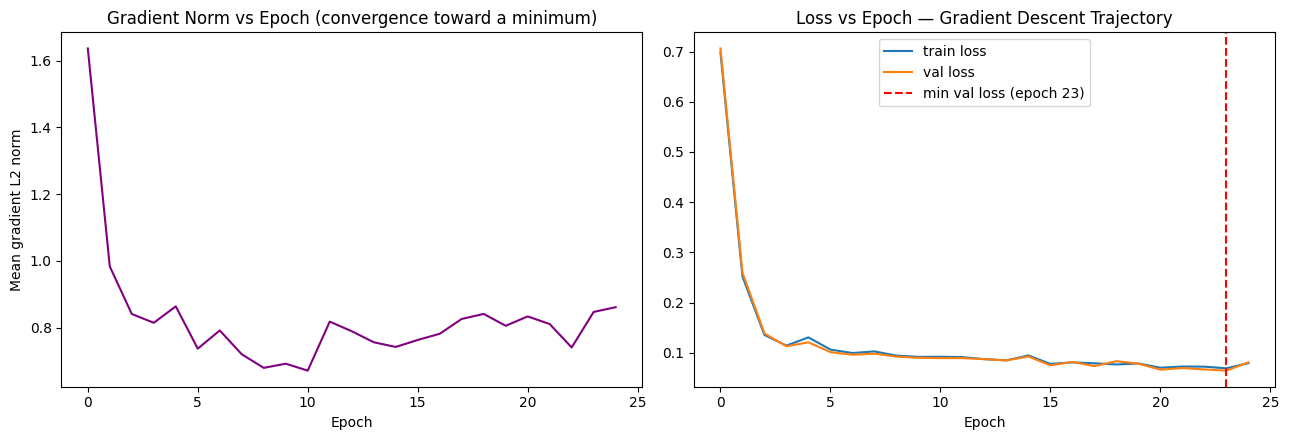

In [ ]:
def manual_training_loop(model, X_tr, y_tr, X_v, y_v, epochs=25, batch_size=64):
    optimizer = tf.keras.optimizers.Adam(learning_rate=BEST_LR)
    loss_fn = tf.keras.losses.CategoricalCrossentropy()

    grad_norms, train_losses, val_losses = [], [], []
    n_batches = len(X_tr) // batch_size

    for epoch in range(epochs):
        epoch_grad_norms = []
        idx = np.random.permutation(len(X_tr))
        for b in range(n_batches):
            batch_idx = idx[b*batch_size:(b+1)*batch_size]
            xb, yb = X_tr[batch_idx], y_tr[batch_idx]
            with tf.GradientTape() as tape:
                preds = model(xb, training=True)
                loss = loss_fn(yb, preds)
            grads = tape.gradient(loss, model.trainable_variables)
            grad_norm = tf.sqrt(sum(tf.reduce_sum(tf.square(g)) for g in grads if g is not None))
            epoch_grad_norms.append(float(grad_norm))
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        train_pred = model(X_tr, training=False)
        val_pred = model(X_v, training=False)
        train_losses.append(float(loss_fn(y_tr, train_pred)))
        val_losses.append(float(loss_fn(y_v, val_pred)))
        grad_norms.append(np.mean(epoch_grad_norms))
        print(f"Epoch {epoch+1}/{epochs} — train_loss={train_losses[-1]:.4f}, "
              f"val_loss={val_losses[-1]:.4f}, grad_norm={grad_norms[-1]:.4f}")

    return grad_norms, train_losses, val_losses

grad_model = build_cnn_baseline()
grad_norms, gm_train_loss, gm_val_loss = manual_training_loop(
    grad_model, X_train_n, y_train_oh, X_val_n, y_val_oh, epochs=25
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(grad_norms, color='purple')
ax[0].set_title("Gradient Norm vs Epoch (convergence toward a minimum)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Mean gradient L2 norm")

ax[1].plot(gm_train_loss, label='train loss')
ax[1].plot(gm_val_loss, label='val loss')
best_ep = int(np.argmin(gm_val_loss))
ax[1].axvline(best_ep, color='red', linestyle='--', label=f'min val loss (epoch {best_ep})')
ax[1].set_title("Loss vs Epoch — Gradient Descent Trajectory")
ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout()
plt.savefig("08_gradient_convergence.png", dpi=150)
plt.show()


## 12. Evaluation (CO3 — Required Metrics)

Confusion matrix, accuracy, precision, recall, F1 (macro + per-class), specificity, ROC-AUC, and ROC curves.


=== CNN_Baseline — Test Set Results ===
Accuracy:    0.9087
Precision:   0.9101
Recall:      0.9111
F1 (macro):  0.9105
Specificity: 0.9817
ROC-AUC:     0.9889
                    precision    recall  f1-score   support

           WALKING       0.99      1.00      1.00       496
  WALKING_UPSTAIRS       0.97      0.95      0.96       471
WALKING_DOWNSTAIRS       0.95      0.98      0.97       420
           SITTING       0.75      0.78      0.76       491
          STANDING       0.80      0.76      0.78       532
            LAYING       0.99      1.00      1.00       537

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



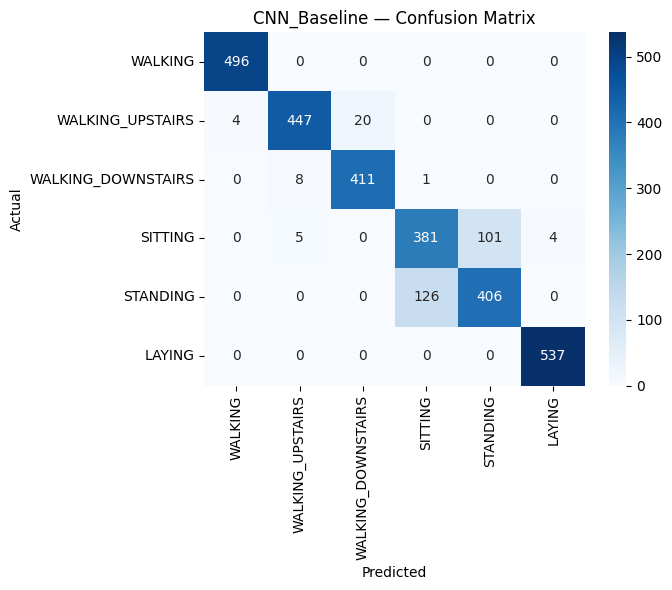

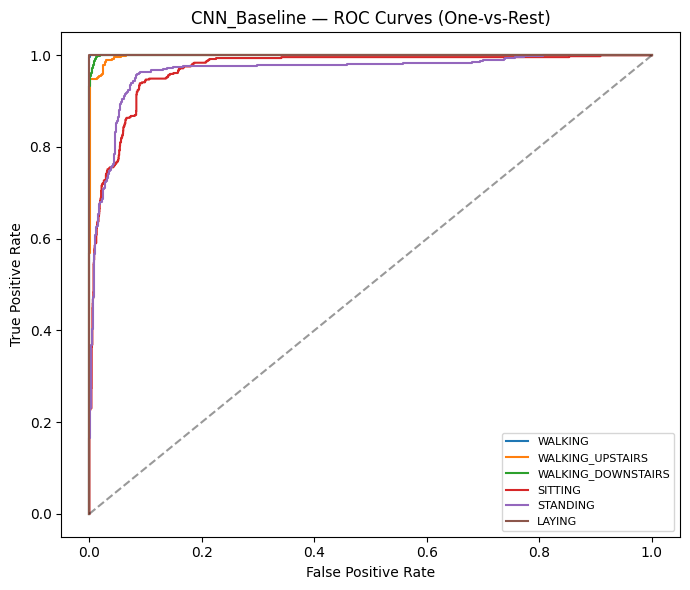


=== CNN_LSTM — Test Set Results ===
Accuracy:    0.9141
Precision:   0.9153
Recall:      0.9159
F1 (macro):  0.9148
Specificity: 0.9828
ROC-AUC:     0.9871
                    precision    recall  f1-score   support

           WALKING       0.99      0.94      0.96       496
  WALKING_UPSTAIRS       0.99      0.95      0.97       471
WALKING_DOWNSTAIRS       0.89      0.99      0.94       420
           SITTING       0.82      0.77      0.79       491
          STANDING       0.81      0.84      0.83       532
            LAYING       0.99      1.00      0.99       537

          accuracy                           0.91      2947
         macro avg       0.92      0.92      0.91      2947
      weighted avg       0.92      0.91      0.91      2947



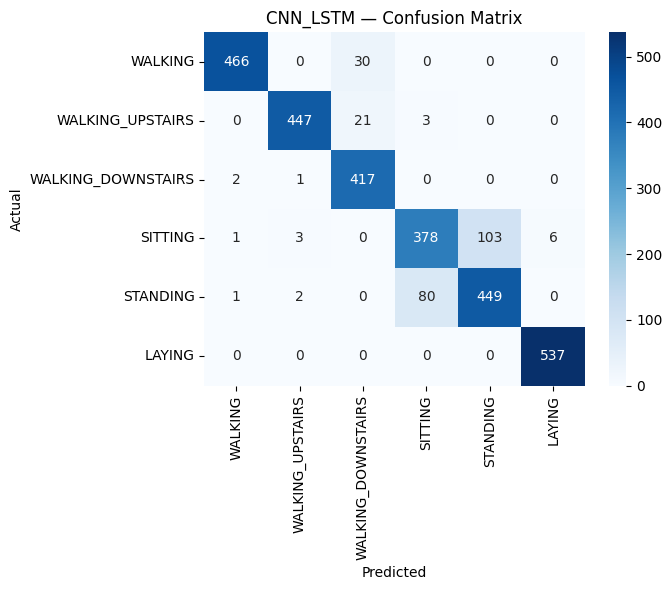

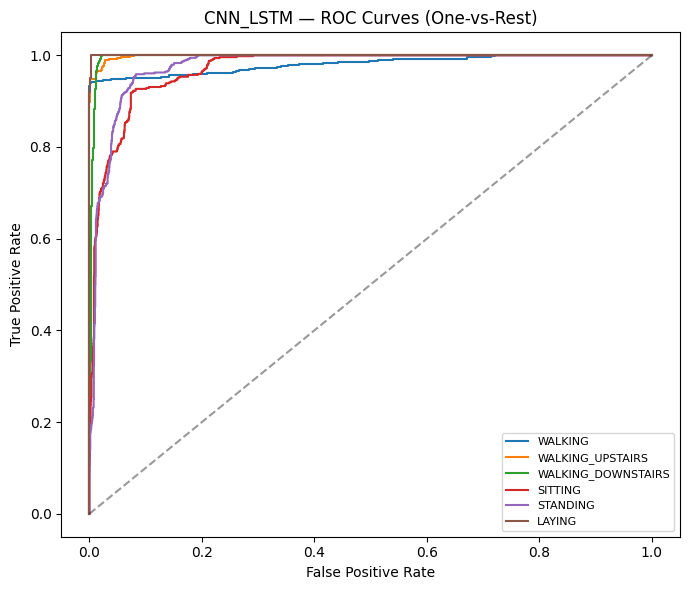


=== CNN_LSTM_Attention_Proposed — Test Set Results ===
Accuracy:    0.9172
Precision:   0.9180
Recall:      0.9199
F1 (macro):  0.9177
Specificity: 0.9835
ROC-AUC:     0.9896
                    precision    recall  f1-score   support

           WALKING       0.96      0.95      0.95       496
  WALKING_UPSTAIRS       0.98      0.95      0.96       471
WALKING_DOWNSTAIRS       0.90      1.00      0.94       420
           SITTING       0.78      0.84      0.81       491
          STANDING       0.89      0.78      0.83       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



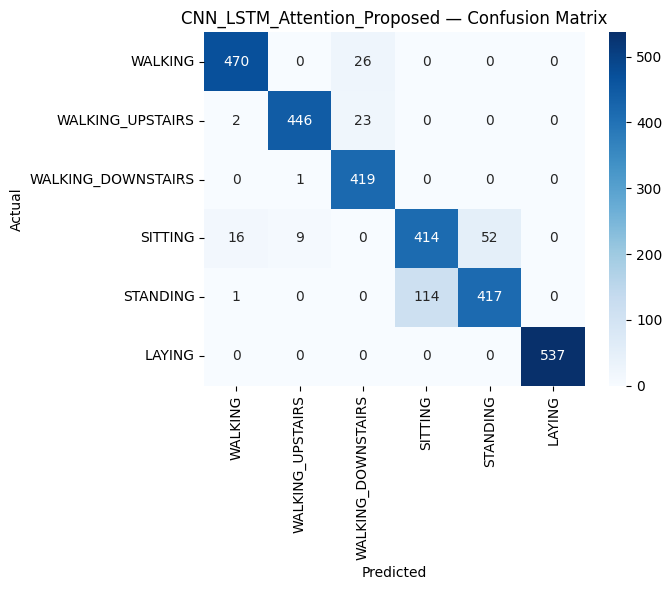

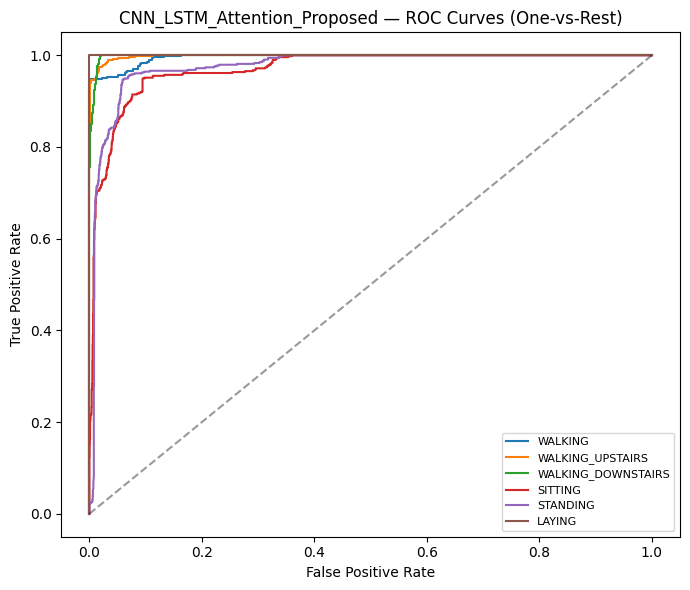

In [ ]:
def evaluate_model(model, X_te, y_te_int, name):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_te_int, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_te_int, y_pred, average='macro', zero_division=0)

    cm = confusion_matrix(y_te_int, y_pred)
    specificities = []
    for i in range(num_classes):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        specificities.append(tn / (tn + fp + 1e-8))
    macro_specificity = np.mean(specificities)

    y_te_bin = label_binarize(y_te_int, classes=list(range(num_classes)))
    auc = roc_auc_score(y_te_bin, y_prob, average='macro', multi_class='ovr')

    print(f"\n=== {name} — Test Set Results ===")
    print(f"Accuracy:    {acc:.4f}\nPrecision:   {precision:.4f}\nRecall:      {recall:.4f}")
    print(f"F1 (macro):  {f1:.4f}\nSpecificity: {macro_specificity:.4f}\nROC-AUC:     {auc:.4f}")
    print(classification_report(y_te_int, y_pred, target_names=ACTIVITY_NAMES, zero_division=0))

    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ACTIVITY_NAMES, yticklabels=ACTIVITY_NAMES)
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"09_confusion_matrix_{name}.png", dpi=150)
    plt.show()

    # ROC curves (one-vs-rest, macro)
    plt.figure(figsize=(7,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{ACTIVITY_NAMES[i]}")
    plt.plot([0,1], [0,1], 'k--', alpha=0.4)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{name} — ROC Curves (One-vs-Rest)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"10_roc_curve_{name}.png", dpi=150)
    plt.show()

    return {"accuracy": acc, "precision": precision, "recall": recall,
            "f1": f1, "specificity": macro_specificity, "auc": auc}

eval_results = {}
for name, r in results.items():
    eval_results[name] = evaluate_model(r["model"], X_test_n, y_test, name)


## 13. Computational Cost & Trainable Parameters

In [ ]:
cost_df = pd.DataFrame(compute_cost)
cost_df.to_csv("computational_cost.csv", index=False)
cost_df


,Model,Trainable Params,Training Time (s),Epochs Run
0,CNN_Baseline,53446,37.6,50
1,CNN_LSTM,143254,80.8,50
2,CNN_LSTM_Attention_Proposed,195138,95.7,50


## 14. Ablation Study (CO5 — Innovation Evidence)

In [ ]:
ablation_df = pd.DataFrame({
    "Experiment": ["Baseline (CNN only)", "Experiment 1 (CNN + LSTM)", "Proposed (CNN + LSTM + Attention)"],
    "CNN": ["Yes", "Yes", "Yes"],
    "LSTM": ["No", "Yes", "Yes"],
    "Attention": ["No", "No", "Yes"],
    "Accuracy": [eval_results["CNN_Baseline"]["accuracy"],
                 eval_results["CNN_LSTM"]["accuracy"],
                 eval_results["CNN_LSTM_Attention_Proposed"]["accuracy"]],
    "F1 (macro)": [eval_results["CNN_Baseline"]["f1"],
                   eval_results["CNN_LSTM"]["f1"],
                   eval_results["CNN_LSTM_Attention_Proposed"]["f1"]],
})
ablation_df.to_csv("ablation_results.csv", index=False)
ablation_df


,Experiment,CNN,LSTM,Attention,Accuracy,F1 (macro)
0,Baseline (CNN only),Yes,No,No,0.908721,0.910456
1,Experiment 1 (CNN + LSTM),Yes,Yes,No,0.914150,0.914750
2,Proposed (CNN + LSTM + Attention),Yes,Yes,Yes,0.917204,0.917663


## 15. Comparative Analysis vs. Published SOTA (CO4)

Reported test-set numbers from published work on the **same UCI HAR dataset**.

References:
- Stacked LSTM (~93.1%) — *"Activity and Subject Detection for UCI HAR Dataset with & without missing Sensor Data"*, arXiv:2505.06730
- LSTM-CNN, Lyu et al. (~98.4%) — *"Human Activity Recognition using Wearable Sensors: Review, Challenges, Evaluation Benchmark"*, arXiv:2101.01665
- CNN-LSTM + Self-Attention (~93.1%) — *"Deep CNN-LSTM With Self-Attention Model for Human Activity Recognition Using Wearable Sensor"*, PMC9252338

> These are numbers reported in the cited papers (not re-run locally) — state this explicitly in your README, as recommended when you don't have access to the original code/splits.

In [ ]:
proposed = eval_results["CNN_LSTM_Attention_Proposed"]
proposed_params = MODEL_BUILDERS["CNN_LSTM_Attention_Proposed"]().count_params()

comparison_df = pd.DataFrame({
    "Model": ["Stacked LSTM (literature)", "LSTM-CNN, Lyu et al. (literature)",
              "CNN-LSTM + Self-Attention (literature)", "Proposed Model (this project)"],
    "Accuracy": [0.931, 0.984, 0.931, proposed["accuracy"]],
    "Precision": [None, None, None, proposed["precision"]],
    "Recall": [None, None, None, proposed["recall"]],
    "F1": [None, None, None, proposed["f1"]],
    "AUC": [None, None, None, proposed["auc"]],
    "Parameters": [None, None, None, proposed_params],
    "Source": ["arXiv:2505.06730", "arXiv:2101.01665 (Lyu et al.)", "PMC9252338", "This work"]
})
comparison_df.to_csv("sota_comparison.csv", index=False)
comparison_df


,Model,Accuracy,Precision,Recall,F1,AUC,Parameters,Source
0,Stacked LSTM (literature),0.931000,NaN,NaN,NaN,NaN,NaN,arXiv:2505.06730
1,"LSTM-CNN, Lyu et al. (literature)",0.984000,NaN,NaN,NaN,NaN,NaN,arXiv:2101.01665 (Lyu et al.)
2,CNN-LSTM + Self-Attention (literature),0.931000,NaN,NaN,NaN,NaN,NaN,PMC9252338
3,Proposed Model (this project),0.917204,0.917955,0.919855,0.917663,0.989609,195138.0,This work


## 16. Save Everything for Submission

In [ ]:
import shutil

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

for f in os.listdir("."):
    if f.endswith(".png") or f.endswith(".csv"):
        shutil.move(f, os.path.join("results", f))

for name, r in results.items():
    r["model"].save(f"models/{name}.keras")

print("Saved all figures/CSVs to results/, all trained models to models/")
print("results/:", sorted(os.listdir("results")))
print("models/:", sorted(os.listdir("models")))


Saved all figures/CSVs to results/, all trained models to models/
results/: ['01_class_distribution.png', '02_sample_signals_per_activity.png', '03_channel_correlation.png', '04_magnitude_boxplot.png', '05_bias_variance_tradeoff.png', '06_cross_validation.png', '07_training_curve_CNN_Baseline.png', '07_training_curve_CNN_LSTM.png', '07_training_curve_CNN_LSTM_Attention_Proposed.png', '08_gradient_convergence.png', '09_confusion_matrix_CNN_Baseline.png', '09_confusion_matrix_CNN_LSTM.png', '09_confusion_matrix_CNN_LSTM_Attention_Proposed.png', '10_roc_curve_CNN_Baseline.png', '10_roc_curve_CNN_LSTM.png', '10_roc_curve_CNN_LSTM_Attention_Proposed.png', 'ablation_results.csv', 'computational_cost.csv', 'hyperparameter_search.csv', 'sota_comparison.csv']
models/: ['CNN_Baseline.keras', 'CNN_LSTM.keras', 'CNN_LSTM_Attention_Proposed.keras']


In [ ]:
# ---------------------------------------------------------
# Prediction Cell — run inference with the trained proposed model
# ---------------------------------------------------------

# Use the final proposed model (CNN + LSTM + Attention)
best_model = results["CNN_LSTM_Attention_Proposed"]["model"]

def predict_activity(model, X_window, true_label=None):
    """
    X_window: a single window of shape (128, 9) or a batch (N, 128, 9)
    Returns predicted label(s), confidence, and full probability vector.
    """
    if X_window.ndim == 2:
        X_window = np.expand_dims(X_window, axis=0)  # (1, 128, 9)

    probs = model.predict(X_window, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    confidence = np.max(probs, axis=1)

    for i in range(len(pred_idx)):
        pred_name = ACTIVITY_NAMES[pred_idx[i]]
        line = f"Predicted: {pred_name}  (confidence: {confidence[i]*100:.2f}%)"
        if true_label is not None:
            true_name = ACTIVITY_NAMES[true_label[i]] if hasattr(true_label, "__len__") else ACTIVITY_NAMES[true_label]
            correct = "✅" if pred_name == true_name else "❌"
            line += f"   |   Actual: {true_name}  {correct}"
        print(line)

    return pred_idx, probs

# --- Example 1: predict on a single random test sample ---
sample_idx = np.random.randint(0, len(X_test_n))
print("=== Single sample prediction ===")
predict_activity(best_model, X_test_n[sample_idx], true_label=y_test[sample_idx])

# --- Example 2: predict on a batch (first 10 test samples) and show a results table ---
print("\n=== Batch prediction (first 10 test samples) ===")
pred_idx, probs = predict_activity(best_model, X_test_n[:10], true_label=y_test[:10])

pred_table = pd.DataFrame({
    "Actual": [ACTIVITY_NAMES[i] for i in y_test[:10]],
    "Predicted": [ACTIVITY_NAMES[i] for i in pred_idx],
    "Confidence (%)": [f"{p.max()*100:.2f}" for p in probs],
    "Correct": [ACTIVITY_NAMES[y_test[i]] == ACTIVITY_NAMES[pred_idx[i]] for i in range(10)]
})
display(pred_table)

# --- Example 3: predict on a completely new/custom raw window ---
# Replace this with your own 128-timestep x 9-channel sensor reading if you have one.
# It must be normalized using the SAME mean/std computed from the training set.
custom_window_raw = X_test[sample_idx]          # placeholder: swap with real new data
custom_window_norm = (custom_window_raw - mean) / std
print("\n=== Custom/new sample prediction ===")
predict_activity(best_model, custom_window_norm)

=== Single sample prediction ===
Predicted: WALKING  (confidence: 99.85%)   |   Actual: WALKING  ✅

=== Batch prediction (first 10 test samples) ===
Predicted: STANDING  (confidence: 99.95%)   |   Actual: STANDING  ✅
Predicted: STANDING  (confidence: 99.96%)   |   Actual: STANDING  ✅
Predicted: STANDING  (confidence: 99.96%)   |   Actual: STANDING  ✅
Predicted: STANDING  (confidence: 99.96%)   |   Actual: STANDING  ✅
Predicted: STANDING  (confidence: 99.96%)   |   Actual: STANDING  ✅
Predicted: STANDING  (confidence: 99.96%)   |   Actual: STANDING  ✅
Predicted: STANDING  (confidence: 99.96%)   |   Actual: STANDING  ✅
Predicted: STANDING  (confidence: 99.96%)   |   Actual: STANDING  ✅
Predicted: STANDING  (confidence: 99.96%)   |   Actual: STANDING  ✅
Predicted: STANDING  (confidence: 99.96%)   |   Actual: STANDING  ✅


,Actual,Predicted,Confidence (%),Correct
0,STANDING,STANDING,99.95,True
1,STANDING,STANDING,99.96,True
2,STANDING,STANDING,99.96,True
3,STANDING,STANDING,99.96,True
4,STANDING,STANDING,99.96,True
5,STANDING,STANDING,99.96,True
6,STANDING,STANDING,99.96,True
7,STANDING,STANDING,99.96,True
8,STANDING,STANDING,99.96,True
9,STANDING,STANDING,99.96,True



=== Custom/new sample prediction ===
Predicted: WALKING  (confidence: 99.85%)


(array([0]),
 array([[9.9854112e-01, 7.2462286e-04, 3.2490803e-05, 1.2203504e-05,
         6.4809364e-04, 4.1627918e-05]], dtype=float32))

In [ ]:
!pip freeze | grep -iE "tensorflow|scikit-learn|pandas|matplotlib|seaborn|numpy"


geopandas==1.1.4
matplotlib==3.10.0
matplotlib-inline==0.2.2
matplotlib-venn==1.1.2
numpy==2.1.3
pandas==2.2.3
pandas-datareader==0.11.1
pandas-gbq==0.30.0
pandas-stubs==2.2.3.250527
scikit-learn==1.6.1
seaborn==0.13.2
sklearn-pandas==2.2.0
tensorflow==2.20.0
tensorflow-datasets==4.9.10
tensorflow-hub==0.16.1
tensorflow-metadata==1.21.0
tensorflow-probability==0.25.0
tensorflow-text==2.20.1
